# Bronze layer exploration notebook

### imports and data loading

In [ ]:
import pandas as pd
import numpy as np
from pipeline.bronze_reader import read_bronze_df

# orders
df_orders = read_bronze_df("orders")

# products
df_products = read_bronze_df("products")

# customers
df_customers = read_bronze_df("customers")

### Exploring orders data

In [2]:
df_orders.head(5)

,id,name,createdAt,processedAt,displayFinancialStatus,tags,totalPriceSet.shopMoney.amount,totalPriceSet.shopMoney.currencyCode,customer.id,lineItems.edges,customer
0,gid://shopify/Order/6863460728903,#1944,2026-08-07T08:43:48Z,2025-08-06T21:59:11Z,PAID,"[source:direct, synthetic]",389.85,USD,gid://shopify/Customer/8899950706759,[{'node': {'title': 'VANS | OLD SKOOL (BUTTERF...,NaN
1,gid://shopify/Order/6863063973959,#1593,2026-08-07T07:30:32Z,2025-08-06T22:26:15Z,PAID,"[source:google, synthetic]",649.8,USD,gid://shopify/Customer/8900800446535,[{'node': {'title': 'VANS | AUTHENTIC (BUTTERF...,NaN
2,gid://shopify/Order/6867039912007,#2637,2026-08-07T15:02:08Z,2025-08-07T09:44:12Z,PAID,"[source:organic, synthetic]",2769.65,USD,gid://shopify/Customer/8901292359751,[{'node': {'title': 'ASICS TIGER | GEL-LYTE V ...,NaN
3,gid://shopify/Order/6863064105031,#1594,2026-08-07T07:30:45Z,2025-08-07T10:08:20Z,PAID,"[source:direct, synthetic]",739.9,USD,gid://shopify/Customer/8900800544839,[{'node': {'title': 'PUMA | SUEDE CLASSIC REGA...,NaN
4,gid://shopify/Order/6862370635847,#1219,2026-08-07T05:20:57Z,2025-08-07T13:08:37Z,PAID,"[source:google, synthetic]",1559.5,USD,gid://shopify/Customer/8894398300231,[{'node': {'title': 'ASICS TIGER | GEL-LYTE V ...,NaN


In [3]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    2371 non-null   str    
 1   name                                  2371 non-null   str    
 2   createdAt                             2371 non-null   str    
 3   processedAt                           2371 non-null   str    
 4   displayFinancialStatus                2371 non-null   str    
 5   tags                                  2371 non-null   object 
 6   totalPriceSet.shopMoney.amount        2371 non-null   str    
 7   totalPriceSet.shopMoney.currencyCode  2371 non-null   str    
 8   customer.id                           2328 non-null   str    
 9   lineItems.edges                       2371 non-null   object 
 10  customer                              0 non-null      float64
dtypes: float64(1), object(2), st

C:\Users\Ofek.Grossman\AppData\Local\Temp\ipykernel_27424\1568556579.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_orders.groupby(df_orders['processedAt'].dt.to_period('M')).size().plot(kind='bar', title='Orders by Processed Date Month')


<Axes: title={'center': 'Orders by Processed Date Month'}, xlabel='processedAt'>

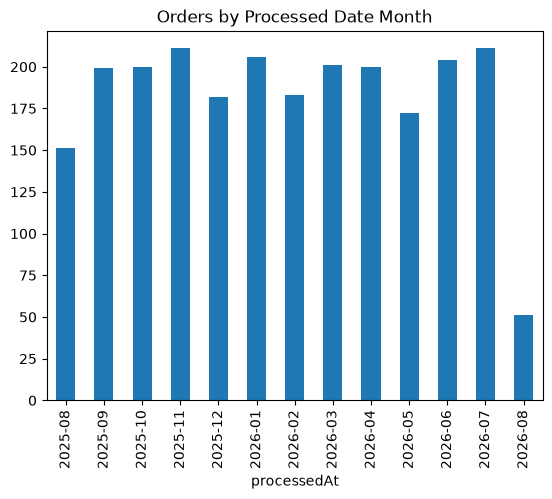

In [4]:
df_orders['processedAt'] = pd.to_datetime(df_orders['processedAt'])
df_orders.groupby(df_orders['processedAt'].dt.to_period('M')).size().plot(kind='bar', title='Orders by Processed Date Month')

### Exploring products data

In [5]:
df_products.head(5)

,id,title,productType,vendor,tags,status,createdAt
0,gid://shopify/Product/7623609647175,The Inventory Not Tracked Snowboard,snowboard,ofek-dev-store,"[Accessory, Sport, Winter]",ACTIVE,2026-08-05T18:31:42Z
1,gid://shopify/Product/7623609679943,Gift Card,giftcard,Snowboard Vendor,[],ACTIVE,2026-08-05T18:31:42Z
2,gid://shopify/Product/7623609778247,The Compare at Price Snowboard,snowboard,ofek-dev-store,"[Accessory, Sport, Winter]",ACTIVE,2026-08-05T18:31:42Z
3,gid://shopify/Product/7623609811015,The Archived Snowboard,snowboard,Snowboard Vendor,"[Archived, Premium, Snow, Snowboard, Sport, Wi...",ARCHIVED,2026-08-05T18:31:42Z
4,gid://shopify/Product/7623609843783,The Draft Snowboard,snowboard,Snowboard Vendor,[],DRAFT,2026-08-05T18:31:42Z


In [6]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           47 non-null     str   
 1   title        47 non-null     str   
 2   productType  47 non-null     str   
 3   vendor       47 non-null     str   
 4   tags         47 non-null     object
 5   status       47 non-null     str   
 6   createdAt    47 non-null     str   
dtypes: object(1), str(6)
memory usage: 2.7+ KB


<Axes: title={'center': 'Products by Product Type'}, xlabel='productType'>

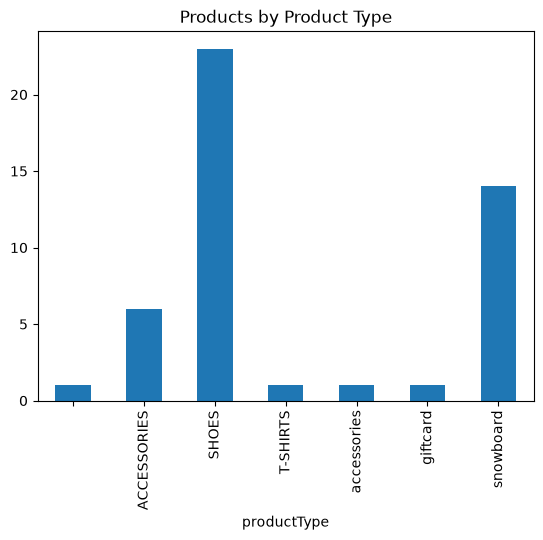

In [7]:
df_products.groupby('productType').size().plot(kind='bar', title='Products by Product Type')

<Axes: title={'center': 'Products by Vendor'}, xlabel='vendor'>

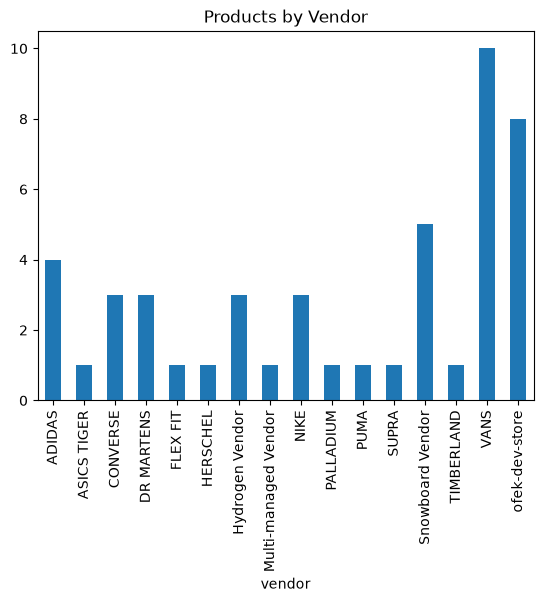

In [8]:
df_products.groupby('vendor').size().plot(kind='bar', title='Products by Vendor')

### Exploring customers data

In [9]:
df_customers.head(5)

,id,createdAt,numberOfOrders,defaultAddress,defaultAddress.city,defaultAddress.country
0,gid://shopify/Customer/8885403746375,2026-08-05T18:31:42Z,8,NaN,NaN,NaN
1,gid://shopify/Customer/8885403779143,2026-08-05T18:31:42Z,9,NaN,Toronto,Canada
2,gid://shopify/Customer/8885403811911,2026-08-05T18:31:42Z,10,NaN,Ottawa,Canada
3,gid://shopify/Customer/8894398070855,2026-08-06T09:32:18Z,10,NaN,13,France
4,gid://shopify/Customer/8894398103623,2026-08-06T09:32:20Z,9,NaN,Barcelona,Spain


In [15]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      919 non-null    str    
 1   createdAt               919 non-null    str    
 2   numberOfOrders          919 non-null    str    
 3   defaultAddress          0 non-null      float64
 4   defaultAddress.city     12 non-null     str    
 5   defaultAddress.country  12 non-null     str    
dtypes: float64(1), str(5)
memory usage: 43.2 KB


<Axes: title={'center': 'Top 20 Customers by Number of Orders'}, xlabel='id'>

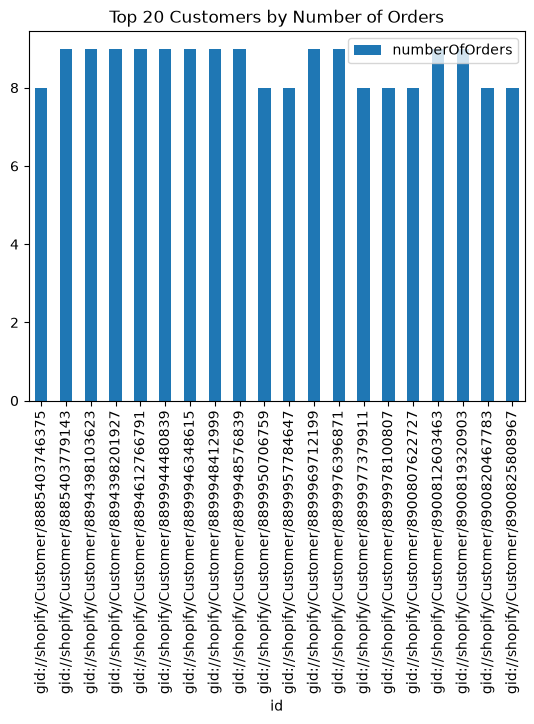

In [21]:
top_20_customers = df_customers.sort_values(by='numberOfOrders', ascending=False).head(20)
top_20_customers['numberOfOrders'] = top_20_customers['numberOfOrders'].astype('int')
top_20_customers.groupby('id').agg({'numberOfOrders': 'sum'}).plot(kind='bar', title='Top 20 Customers by Number of Orders')